In [1]:
import matplotlib
import pylab as plt
import numpy as np
import datetime
from astrometry.util.fits import fits_table
from astrometry.util.starutil_numpy import *
from collections import Counter

In [2]:
# ! text2fits -f jsfsfffffsfffffff ~/medium-band-surveys/mega.stats.tsv ~/medium-band-surveys/mega.stats.fits

In [2]:
T = fits_table('mega.stats.fits')

In [3]:
T.rename('sky(adu/sec)', 'sky')

In [4]:
T.about()

tabledata object with 352705 rows and 17 columns:
   airmass (<class 'numpy.ndarray'>) shape (352705,) dtype >f4
   datetime (<class 'numpy.ndarray'>) shape (352705,) dtype <U19
   domeaz (<class 'numpy.ndarray'>) shape (352705,) dtype >f4
   ellipticity (<class 'numpy.ndarray'>) shape (352705,) dtype >f4
   expnum (<class 'numpy.ndarray'>) shape (352705,) dtype >i4
   exptime (<class 'numpy.ndarray'>) shape (352705,) dtype >f4
   filter (<class 'numpy.ndarray'>) shape (352705,) dtype <U14
   iq (<class 'numpy.ndarray'>) shape (352705,) dtype >f4
   moonalt (<class 'numpy.ndarray'>) shape (352705,) dtype >f4
   moonangl (<class 'numpy.ndarray'>) shape (352705,) dtype >f4
   moonaz (<class 'numpy.ndarray'>) shape (352705,) dtype >f4
   moonphas (<class 'numpy.ndarray'>) shape (352705,) dtype >f4
   moonup (<class 'numpy.ndarray'>) shape (352705,) dtype <U5
   sky (<class 'numpy.ndarray'>) shape (352705,) dtype >f4
   telalt (<class 'numpy.ndarray'>) shape (352705,) dtype >f4
   telaz (<

In [5]:
T.datetime[0], T.datetime[-1]

(np.str_('2003-02-22T09:56:02'), np.str_('2026-01-16T16:08:04'))

In [6]:
len(T)

352705

In [7]:
T.mjd = np.array([datetomjd(datetime.datetime.strptime(t, '%Y-%m-%dT%H:%M:%S')) for t in T.datetime])

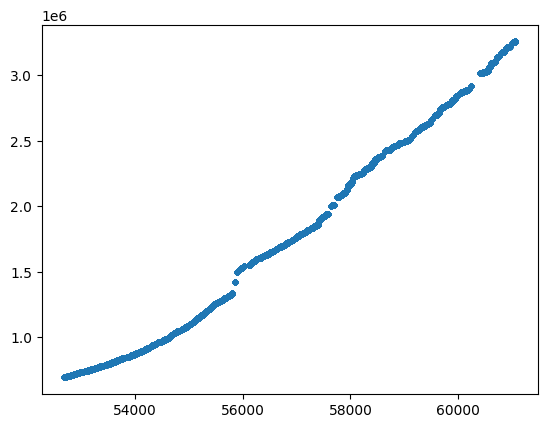

In [8]:
plt.plot(T.mjd, T.expnum, '.');

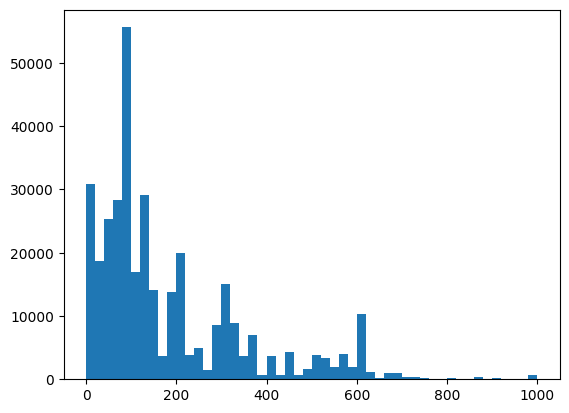

In [9]:
mx = 1000
plt.hist(np.clip(T.exptime, 0, mx), range=(0,mx), bins=50);

In [10]:
Counter(T.filter)

Counter({np.str_('U.MP9302'): 63562,
         np.str_('R.MP9601'): 55605,
         np.str_('R.MP9602'): 53291,
         np.str_('G.MP9401'): 44496,
         np.str_('GRI.MP9605'): 29159,
         np.str_('CAHK.MP9303'): 19196,
         np.str_('U.MP9301'): 18298,
         np.str_('I.MP9702'): 15923,
         np.str_('Z.MP9801'): 15198,
         np.str_('I.MP9701'): 12758,
         np.str_('I.MP9703'): 9905,
         np.str_('G.MP9402'): 7724,
         np.str_('HA.MP9603'): 3709,
         np.str_('Z.MP9901'): 1676,
         np.str_('OIII.MP9501'): 674,
         np.str_('HA.MP7605'): 667,
         np.str_('HAOFF.MP7604'): 192,
         np.str_('N393.MP1111'): 130,
         np.str_('HAOFF.MP9604'): 123,
         np.str_('TIO.MP7701'): 121,
         np.str_('OIII.MP7504'): 114,
         np.str_('CN.MP7803'): 112,
         np.str_('OIIIOFF.MP9502'): 59,
         np.str_('PHG.MP9999'): 8,
         np.str_('NONE'): 4,
         np.str_('OPEN'): 1})

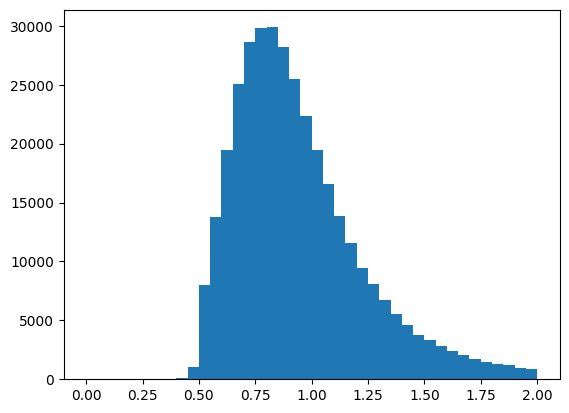

In [11]:
plt.hist(T.iq, range=(0, 2), bins=40);

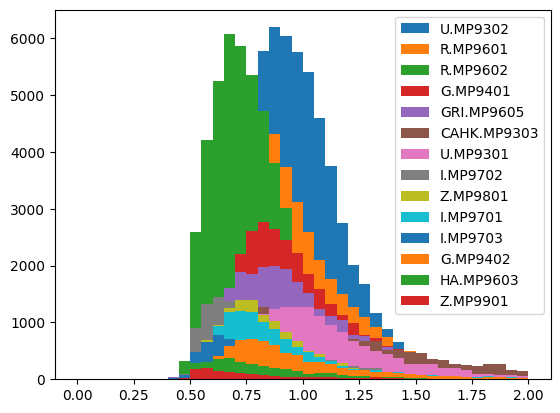

In [12]:
c = Counter(T.filter)
plots = []
for f,n in c.most_common():
    if n < 1000:
        break
    I = np.flatnonzero((T.filter == f) * (T.exptime >= 30))
    n,b,p = plt.hist(T.iq[I], range=(0, 2), bins=40, label=f);#, histtype='step');
    plots.append((n,b,f, T.iq[I]))
plt.legend();

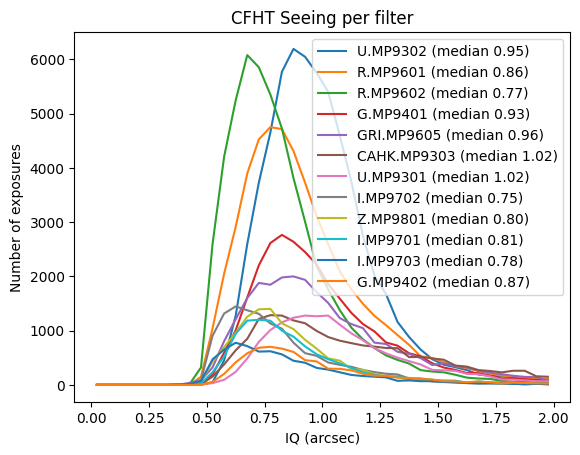

In [13]:
median_iqs = []
for n,b,f,iq in plots:
    if np.sum(n) < 5000:
        break
    bb = b[:-1] + (b[1]-b[0])/2.
    plt.plot(bb, n, label='%s (median %.2f)' % (f, np.median(iq)))
    median_iqs.append((f, np.median(iq)))
plt.legend();
plt.title('CFHT Seeing per filter')
plt.ylabel('Number of exposures')
plt.xlabel('IQ (arcsec)')
plt.savefig('cfht-iq.png')

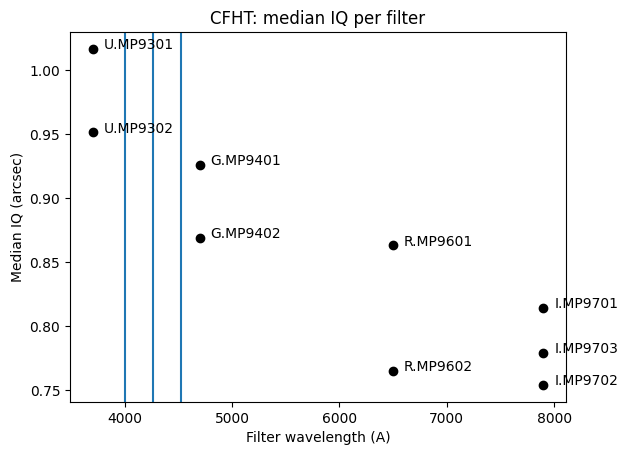

In [14]:
for f,iq in median_iqs:
    filt = f.split('.')[0]
    wave = dict(U=3700, R=6500, G=4700, I=7900)# CAHK=3950, 
    if not filt in wave:
        continue
    plt.plot(wave[filt], iq, 'ko');
    plt.text(wave[filt]+100, iq, f)
plt.ylabel('Median IQ (arcsec)')
plt.xlabel('Filter wavelength (A)');
plt.axvline(4000)
plt.axvline(4260)
plt.axvline(4520)
plt.title('CFHT: median IQ per filter');
plt.savefig('iq-per-filter.png');

In [15]:
U = T[T.filter == 'U.MP9302']
len(U)

63562

In [16]:
G = T[(T.filter == 'G.MP9402') * (T.exptime >= 30)]
len(G)

7184

In [17]:
Gsky = G[G.sky > 0]
len(Gsky)

3156

In [18]:
Counter(Gsky.moonup)

Counter({np.str_('False'): 1786, np.str_('True'): 1370})

In [19]:
U.cut(U.exptime >= 30)
len(U)

61904

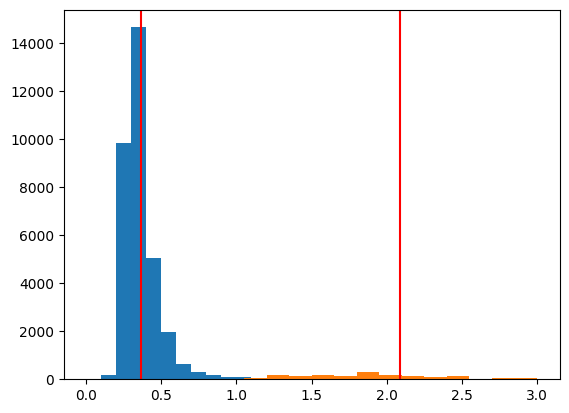

In [20]:
plt.hist(U.sky, range=(0,2), bins=20);

u_sky_diet = 0.58 # e-/sec/pixel
gain = 1.6 # e-/ADU
u_sky_adu = u_sky_diet / gain

plt.axvline(u_sky_adu, color='r');

I = np.flatnonzero(Gsky.moonup == 'False')
plt.hist(Gsky.sky[I], range=(0,3), bins=20);

g_sky_diet = 3.34 # e-/sec/pixel
g_sky_adu = g_sky_diet / gain
plt.axvline(g_sky_adu, color='r');

# u zpt: 25.74
# g zpt: 27.00


In [21]:
Gsky.sky[I]

array([1.9021579, 1.9021579, 1.9008504, ..., 2.05     , 2.05     ,
       1.93     ], shape=(1786,), dtype='>f4')

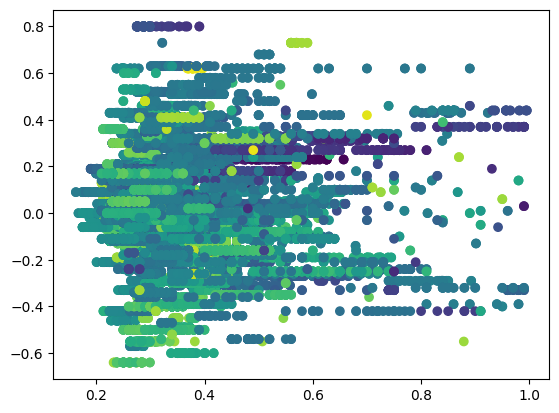

In [22]:
# Many -99 values
I = np.flatnonzero((U.sky > 0) * (U.sky < 1))
plt.scatter(U.sky[I], U.moonphas[I], c=U.moonangl[I]);

(array([30079.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,  2851.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

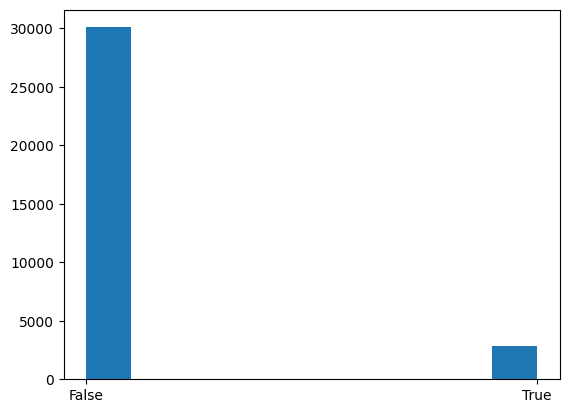

In [23]:
plt.hist(U.moonup[I])

## Overheads

In [24]:
T.mjd

array([52692.41391204, 52692.51821759, 52692.51947917, ...,
       61056.66626157, 61056.66923611, 61056.67226852], shape=(352705,))

In [25]:
T.exptime

array([ 60.,  60.,  60., ..., 120., 120., 120.],
      shape=(352705,), dtype='>f4')

In [27]:
T.overhead = np.zeros(len(T))

In [28]:
T.overhead[:-1] = (T.mjd[1:] - T.mjd[:-1]) * 24 * 3600 - T.exptime[:-1]

In [41]:
T.consecutive = np.zeros(len(T), bool)
T.consecutive[:-1] = ((T.expnum[:-1] + 1) == T.expnum[1:])

In [42]:
Counter(T.consecutive)

Counter({np.True_: 296415, np.False_: 56290})

In [79]:
T.samefilter = np.zeros(len(T), bool)
T.samefilter[:-1] = (T.filter[:-1] == T.filter[1:])

In [80]:
Counter(T.samefilter)

Counter({np.True_: 313678, np.False_: 39027})

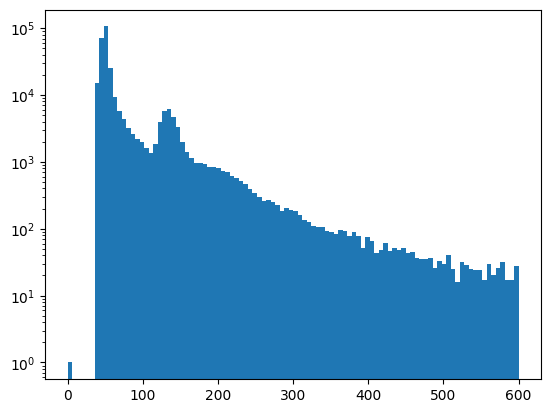

In [43]:
plt.hist(T.overhead[T.consecutive], log=True, range=(0, 600), bins=100);

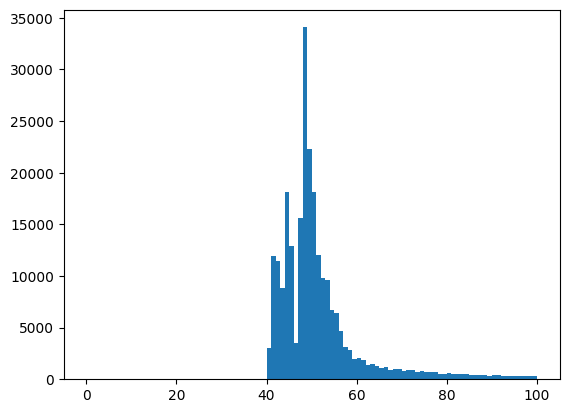

In [44]:
plt.hist(T.overhead[T.consecutive], range=(0, 100), bins=100);

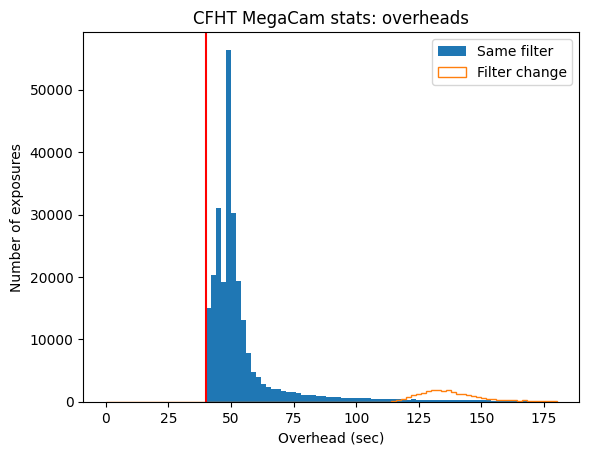

In [84]:
plt.hist(T.overhead[T.consecutive * T.samefilter], range=(0, 180), bins=90, label='Same filter');
plt.hist(T.overhead[T.consecutive * ~T.samefilter], range=(0, 180), bins=90, label='Filter change', histtype='step');
plt.xlabel('Overhead (sec)')
plt.ylabel('Number of exposures');
plt.title('CFHT MegaCam stats: overheads');
plt.axvline(40, color='r')
plt.legend()
plt.savefig('cfht-overhead.png');

In [48]:
from astrometry.util.starutil_numpy import *

In [50]:
T.teldist = np.zeros(len(T))

In [51]:
T.teldist[:-1] = np.array([degrees_between(az1, alt1, az2, alt2) for az1,alt1,az2,alt2 in
                          zip(T.telaz[:-1], T.telalt[:-1], T.telaz[1:], T.telalt[1:])])

In [52]:
Ibad = np.flatnonzero(T.telaz[:-1] == -99)
len(Ibad)

3049

In [53]:
T.teldist[Ibad] = 0

In [54]:
T.teldist[Ibad+1] = 0

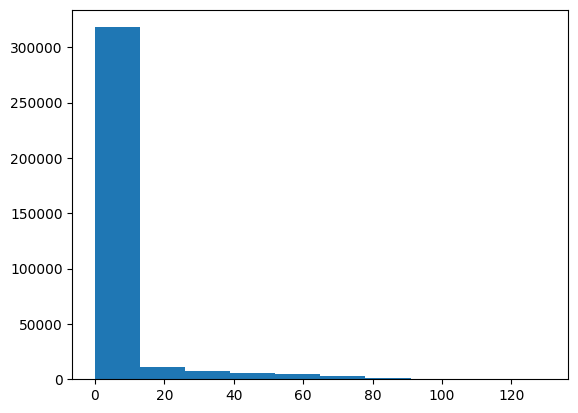

In [57]:
plt.hist(T.teldist);

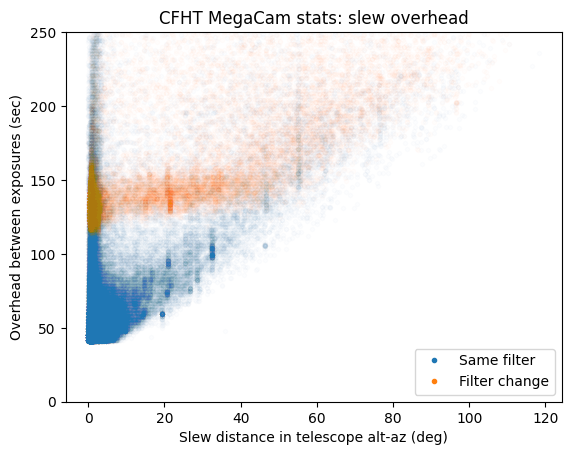

In [96]:
Iok1 = np.flatnonzero(T.consecutive * (T.teldist > 0) * (T.overhead < 250) * (T.overhead > 5) * T.samefilter)
Iok2 = np.flatnonzero(T.consecutive * (T.teldist > 0) * (T.overhead < 250) * (T.overhead > 5) * ~T.samefilter)
p1 = plt.plot(T.teldist[Iok1], T.overhead[Iok1], '.', alpha=0.01)
p2 = plt.plot(T.teldist[Iok2], T.overhead[Iok2], '.', alpha=0.01)
ax = plt.axis()
plt.plot(0,-10, '.', color=p1[0].get_color(), label='Same filter');
plt.plot(0,-10, '.', color=p2[0].get_color(), label='Filter change');
plt.axis(ax)
plt.ylim(0,250)
plt.legend(loc='lower right')
plt.xlabel('Slew distance in telescope alt-az (deg)')
plt.ylabel('Overhead between exposures (sec)')
plt.title('CFHT MegaCam stats: slew overhead');
plt.savefig('cfht-slew.png');

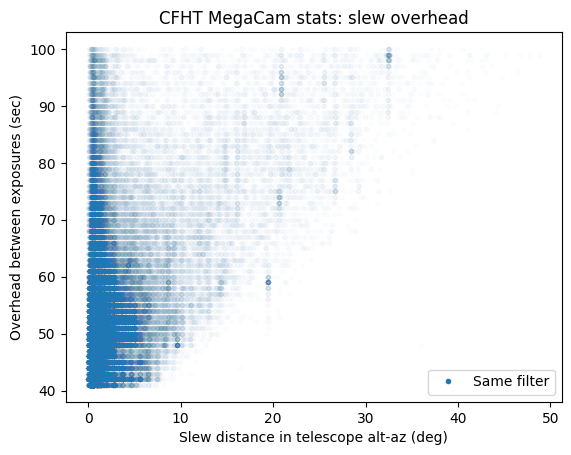

In [97]:
Iok1 = np.flatnonzero(T.consecutive * (T.teldist > 0) * (T.overhead < 100) * (T.overhead > 5) * T.samefilter)
p1 = plt.plot(T.teldist[Iok1], T.overhead[Iok1], '.', alpha=0.01)
ax = plt.axis()
plt.plot(0,-10, '.', color=p1[0].get_color(), label='Same filter');
plt.axis(ax)
plt.legend(loc='lower right')
plt.xlabel('Slew distance in telescope alt-az (deg)')
plt.ylabel('Overhead between exposures (sec)')
plt.title('CFHT MegaCam stats: slew overhead');
plt.savefig('cfht-slew2.png');

In [98]:
len(T)

352705

In [63]:
i = Iok[np.argmin(T.overhead[Iok])]

In [64]:
T[i]

<tabledata object with 1 rows and 21 columns: expnum=980513, datetime=2008-04-05T12:12:47, exptime=320.0, filter=G.MP9401, iq=0.7738, ellipticity=0.0181, moonangl=126.1, moonphas=0.0, moonup=False, moonalt=-46.5, moonaz=58.2, telalt=68.24, telaz=129.42, domeaz=124.0, airmass=1.077, transparency=-99.0, sky=-99.0, mjd=54561.508877314816, overhead=3.9999996731057763, consecutive=True, teldist=1.357424356282808>

In [65]:
T[i+1]

<tabledata object with 1 rows and 21 columns: expnum=980514, datetime=2008-04-05T12:18:11, exptime=320.0, filter=G.MP9401, iq=0.8294, ellipticity=0.0149, moonangl=126.2, moonphas=0.0, moonup=False, moonalt=-45.5, moonaz=59.2, telalt=69.22, telaz=132.01, domeaz=133.2, airmass=1.07, transparency=-99.0, sky=-99.0, mjd=54561.51262731481, overhead=57.00000011827797, consecutive=True, teldist=1.560424206909526>